In [2]:
"""Wrapper to load the actual data using Python."""

from collections.abc import Generator
from pathlib import Path
from typing import ClassVar

import datasets
import nibabel as nib
import numpy as np
from datasets import DownloadManager
from huggingface_hub import HfApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\comds\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
_CITATION = """
@misc{deng2024ctspine1klargescaledatasetspinal,
      title={CTSpine1K: A Large-Scale Dataset for Spinal Vertebrae Segmentation in Computed Tomography},
      author={Yang Deng and Ce Wang and Yuan Hui and Qian Li and Jun Li and Shiwei Luo and Mengke Sun and Quan Quan and Shuxin Yang and You Hao and Pengbo Liu and Honghu Xiao and Chunpeng Zhao and Xinbao Wu and S. Kevin Zhou},
      year={2024},
      eprint={2105.14711},
      archivePrefix={arXiv},
      primaryClass={eess.IV},
      url={https://arxiv.org/abs/2105.14711},
}
"""  # noqa: E501

_DESCRIPTION = """
Spine-related diseases have high morbidity and cause a huge burden of social cost.
Spine imaging is an essential tool for noninvasively visualizing and assessing spinal
pathology. Segmenting vertebrae in computed tomography (CT) images is the basis of
quantitative medical image analysis for clinical diagnosis and surgery planning of
spine diseases. Current publicly available annotated datasets on spinal vertebrae are
small in size. Due to the lack of a large-scale annotated spine image dataset, the
mainstream deep learning-based segmentation methods, which are data-driven, are heavily
restricted. In this paper, we introduce a large-scale spine CT dataset, called CTSpine1K
curated from multiple sources for vertebra segmentation, which contains 1,005 CT volumes
with over 11,100 labeled vertebrae belonging to different spinal conditions. Based on
this dataset, we conduct several spinal vertebrae segmentation experiments to set the
first benchmark. We believe that this large-scale dataset will facilitate further
research in many spine-related image analysis tasks, including but not limited to
vertebrae segmentation, labeling, 3D spine reconstruction from biplanar radiographs,
image super-resolution, and enhancement.
"""

_HOMEPAGE = "https://github.com/MIRACLE-Center/CTSpine1K"

_LICENSE = "CC-BY-NC-SA"


In [3]:
HF_API = HfApi()

_URLS = HF_API.list_repo_files(
    "alexanderdann/CTSpine1K",
    repo_type="dataset",
)


In [4]:
class CTSpine1KBuilderConfig(datasets.BuilderConfig):
    """BuilderConfig for the dataset CTSpine1K."""

    def __init__(
        self,
        *,
        volumetric: bool,
        **kwargs: dict,
    ) -> None:
        """C'tor if the CTSpine1KBuilderConfig.

        Args:
            volumetric: whether we want to use 3D or 2D data.
            kwargs: parameters which can be used to overwrite the BuilderConfig
                and are forwarded to the super class call.

        """
        super().__init__(**kwargs)

        self.citation = _CITATION
        self.homepage = _HOMEPAGE
        self.license = _LICENSE

        self.volumetric = volumetric

In [5]:
class CTSpine1K(datasets.GeneratorBasedBuilder):
    """Dataloading generator for the CTSpine1K dataset."""

    BUILDER_CONFIGS: ClassVar[list[CTSpine1KBuilderConfig]] = [
        CTSpine1KBuilderConfig(
            name="3d",
            volumetric=True,
            description="3D volumes of CT spine scans",
            version=datasets.Version("1.0.0"),
        ),
        CTSpine1KBuilderConfig(
            name="2d",
            volumetric=False,
            description="2D axial slices of CT spine scans",
            version=datasets.Version("1.0.0"),
        ),
    ]

    def _info(self) -> datasets.DatasetInfo:
        if self.config.volumetric:
            features = datasets.Features(
                {
                    "image": datasets.Array3D(
                        shape=(None, 512, 512),
                        dtype="float32",
                    ),
                    "segmentation": datasets.Array3D(
                        shape=(None, 512, 512),
                        dtype="int32",
                    ),
                    "patient_id": datasets.Value("string"),
                    "index": datasets.Value("int32"),
                },
            )
        else:
            features = datasets.Features(
                {
                    "image": datasets.Array2D(shape=(512, 512), dtype="float32"),
                    "segmentation": datasets.Array2D(shape=(512, 512), dtype="int32"),
                    "patient_id": datasets.Value("string"),
                    "index": datasets.Value("int32"),
                    "slice_index": datasets.Value("int32"),
                },
            )

        return datasets.DatasetInfo(
            description=_DESCRIPTION,
            features=features,
            homepage=_HOMEPAGE,
            citation=_CITATION,
            license=_LICENSE,
            # Add citation and other metadata here
        )

    def _split_generators(
        self,
        dl_manager: DownloadManager,
    ) -> list[datasets.GeneratorBasedBuilder]:
        split_file_idx = _URLS.index("metadata/data_split.txt")
        downloaded_files = dl_manager.download(_URLS)

        training, validation, test = self._load_split(downloaded_files[split_file_idx])

        lookup = self._validate_check(downloaded_files)

        return [
            datasets.SplitGenerator(
                name=datasets.Split.TRAIN,
                gen_kwargs={"pairs": [lookup[stem] for stem in training]},
            ),
            datasets.SplitGenerator(
                name=datasets.Split.VALIDATION,
                gen_kwargs={"pairs": [lookup[stem] for stem in validation]},
            ),
            datasets.SplitGenerator(
                name=datasets.Split.TEST,
                gen_kwargs={"pairs": [lookup[stem] for stem in test]},
            ),
        ]

    @staticmethod
    def _load_split(file: str) -> tuple[list[str]]:
        """Load the training, validation and test split.

        Currently this component assumes that the names always come in pairs
        with identical names in the data and labels. The only difference is the
        additional '_labels' after the name off the file.

        Returns:
            Tuples containg the lists for each split.

        """
        split_file = Path(file)
        split_data = split_file.read_text()
        split_list = split_data.split("\n")

        train_ident = split_list.index("trainset:")
        test_public_ident = split_list.index("test_public:")
        test_private_ident = split_list.index("test_private:")

        training = split_list[
            train_ident + 1 : test_public_ident - 1
        ]  # removing white space
        validation = split_list[
            test_public_ident + 1 : test_private_ident - 1
        ]  # removing white space
        test = split_list[test_private_ident + 1 :]

        return training, validation, test

    def _validate_check(self, files: list[str]) -> dict:
        ffiles = sorted(file for file in files if "nii.gz" in file)

        data_candidates = []
        label_candidates = []

        for file in ffiles:
            if "volumes" in file:
                data_candidates.append(file)

                # construction check to ensure data exists
                label = file.split(".nii.gz")
                label = label[0] + "_seg.nii.gz"
                label = label.replace("volumes", "labels")
                label_candidates.append(label)

        if len(data_candidates) != len(label_candidates):
            msg = (
                "Data and labels mismatch. Data is probably not downloaded fully. ",
                f"Got {len(data_candidates)} vs {len(label_candidates)}",
            )
            raise RuntimeError(msg)

        pairs: list[tuple[str, str]] = zip(
            data_candidates,
            label_candidates,
            strict=True,
        )
        lookup = {}
        for input_, label in pairs:
            file_path, segmentation_path = Path(input_), Path(label)

            if not ((file_path).is_file() and (segmentation_path).is_file()):
                msg = (
                    "Data is not a file. Ensure all data was downloaded successfully."
                    f"Failed for {file_path} and {segmentation_path}."
                )
                raise RuntimeError(msg)

            image_slices = self._get_sample_length(file_path)
            segmentation_slices = self._get_sample_length(segmentation_path)
            if image_slices != segmentation_slices:
                msg = (
                    f"Detected files with different slice count for {file_path} "
                    f"and {segmentation_path}. Image slices ({image_slices}) are not "
                    f"equal to segmentation slices ({segmentation_slices})."
                )
                raise ValueError(msg)

            # convert 'some/path/to/file/dummy_123.nii.gz' to dummy_123.nii.gz
            stem = file_path.name
            if stem.removesuffix(".nii.gz") not in label:
                msg = f"Mismatch in sorted pairs. {input_} vs. {label}"
                raise ValueError(msg)

            lookup[stem] = (file_path, segmentation_path)

        return lookup

    @staticmethod
    def _get_sample_length(file_path: Path) -> int:
        expected_ndim = 3
        img = nib.load(file_path)  # this only loads the header
        shape = img.shape
        assert len(shape) == expected_ndim

        return shape[2]

    @staticmethod
    def _volumetric_sample(path: Path) -> np.ndarray:
        volume = nib.load(path)
        volume = volume.get_fdata()
        return np.transpose(volume, (2, 0, 1))

    def _generate_examples(self, pairs: list[tuple[Path, Path]]) -> Generator:
        for pair_idx, (volume_path, label_path) in enumerate(pairs):
            patient_id = Path(volume_path.stem).stem
            image = self._volumetric_sample(volume_path)
            segmentation = self._volumetric_sample(label_path).astype(np.uint32)

            if self.config.volumetric:
                yield (
                    patient_id,
                    {
                        "image": image,
                        "segmentation": segmentation,
                        "patient_id": patient_id,
                        "index": pair_idx,
                    },
                )
            else:
                for idx in range(image.shape[0]):  # iterate over axial slices
                    yield (
                        patient_id + f"_{idx}",
                        {
                            "image": image[idx],
                            "segmentation": segmentation[idx],
                            "patient_id": patient_id,
                            "index": pair_idx,
                            "slice_index": idx,
                        },
                    )


In [6]:
# openpyxl이 없다는 에러가 나면 아래 줄의 주석을 해제하고 실행하세요.
# !{sys.executable} -m pip install openpyxl matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [7]:
file_path = r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\metadata\metadata_colonog.xlsx"

metadata = pd.read_excel(file_path, engine="openpyxl")
metadata.head()

,Collection,Patient Id,Study Date,Study Description,Modality,Series Description,Manufacturer,Manufacturer Model,Software Version,Series UID,Pathology
0,CT COLONOGRAPHY,1.3.6.1.4.1.9328.50.4.0001,01/01/2000,Abdomen^24ACRIN_Colo_IRB2415-04 (Adult),CT,Topo prone 0.6 T20s,SIEMENS,Sensation 64,syngo CT 2005A,1.3.6.1.4.1.9328.50.4.1224,NaN
1,CT COLONOGRAPHY,1.3.6.1.4.1.9328.50.4.0002,01/01/2000,Abdomen^24ACRIN_Colo_IRB2415-04 (Adult),CT,Topo prone 0.6 T20s,SIEMENS,Sensation 64,syngo CT 2005A,1.3.6.1.4.1.9328.50.4.2317,NaN
2,CT COLONOGRAPHY,1.3.6.1.4.1.9328.50.4.0003,01/01/2000,Abdomen^24ACRIN_Colo_IRB2415-04 (Adult),CT,Topo prone 0.6 T20s,SIEMENS,Sensation 64,syngo CT 2005A,1.3.6.1.4.1.9328.50.4.3741,NaN
3,CT COLONOGRAPHY,1.3.6.1.4.1.9328.50.4.0004,01/01/2000,Abdomen^24ACRIN_Colo_IRB2415-04 (Adult),CT,Topo prone 0.6 T20s,SIEMENS,Sensation 64,syngo CT 2005A,1.3.6.1.4.1.9328.50.4.4911,Sacral lumbarization
4,CT COLONOGRAPHY,1.3.6.1.4.1.9328.50.4.0005,01/01/2000,Abdomen^22 COLON SUPINE,CT,Topogram 1.0 T20s,SIEMENS,Sensation 16,VA70C,1.3.6.1.4.1.9328.50.4.5515,NaN


In [8]:
print("데이터 크기:", metadata.shape)
display(metadata.info())
display(metadata.describe(include="all").T)

데이터 크기: (784, 11)
<class 'pandas.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Collection          784 non-null    str  
 1   Patient Id          784 non-null    str  
 2   Study Date          784 non-null    str  
 3   Study Description   749 non-null    str  
 4   Modality            784 non-null    str  
 5   Series Description  740 non-null    str  
 6   Manufacturer        750 non-null    str  
 7   Manufacturer Model  750 non-null    str  
 8   Software Version    750 non-null    str  
 9   Series UID          784 non-null    str  
 10  Pathology           25 non-null     str  
dtypes: str(11)
memory usage: 188.7 KB


None

,count,unique,top,freq
Collection,784,1,CT COLONOGRAPHY,784
Patient Id,784,778,1.3.6.1.4.1.9328.50.4.0305,2
Study Date,784,28,01/01/2000,750
Study Description,749,54,Abdomen^24ACRIN_Colo_IRB2415-04 (Adult),100
Modality,784,1,CT,784
Series Description,740,68,Topogram 0.6 T20s,78
Manufacturer,750,4,SIEMENS,477
Manufacturer Model,750,8,Sensation 64,281
Software Version,750,14,syngo CT 2005A,208
Series UID,784,784,1.3.6.1.4.1.9328.50.4.1224,1


,missing_count,missing_rate_percent
Pathology,759,96.81
Series Description,44,5.61
Study Description,35,4.46
Software Version,34,4.34
Manufacturer Model,34,4.34
Manufacturer,34,4.34
Collection,0,0.00
Study Date,0,0.00
Patient Id,0,0.00
Modality,0,0.00


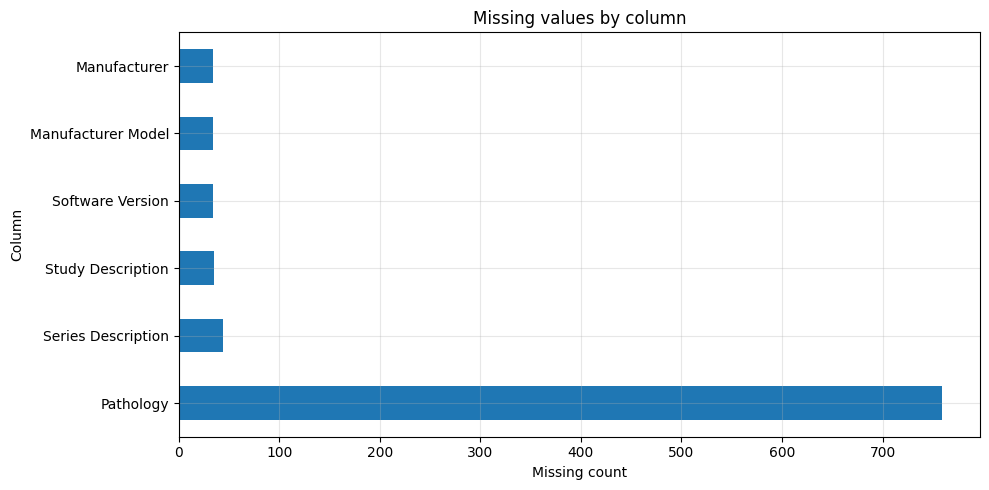

In [9]:
missing = metadata.isna().sum().sort_values(ascending=False)
missing_rate = (missing / len(metadata) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_rate_percent": missing_rate,
})
display(missing_table)

ax = missing[missing > 0].plot(kind="barh")
ax.set_title("Missing values by column")
ax.set_xlabel("Missing count")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

,n_unique
Series UID,784
Patient Id,778
Series Description,68
Study Description,54
Study Date,28
Software Version,14
Manufacturer Model,8
Manufacturer,4
Pathology,2
Collection,1


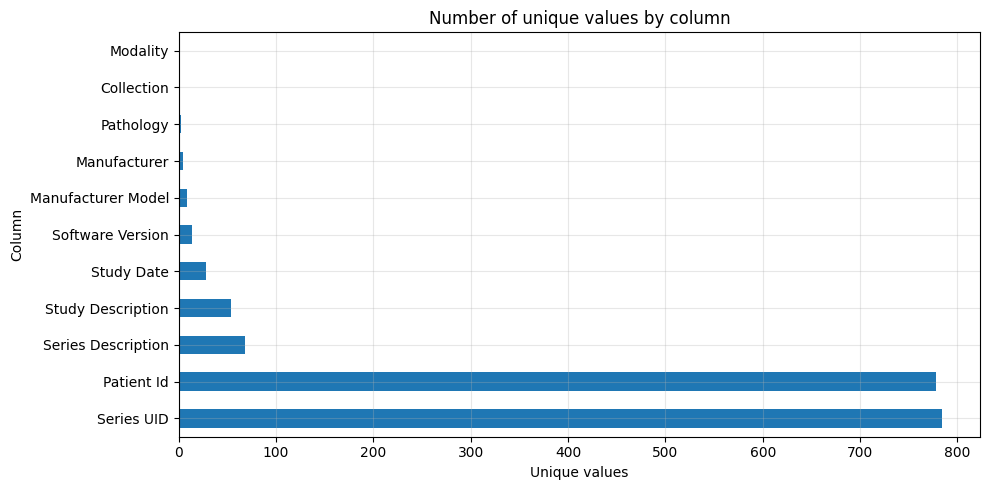

In [10]:
nunique = metadata.nunique(dropna=True).sort_values(ascending=False)
display(nunique.to_frame("n_unique"))

ax = nunique.plot(kind="barh")
ax.set_title("Number of unique values by column")
ax.set_xlabel("Unique values")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
import nibabel as nib
import pandas as pd

volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\COLONOG")

rows = []

for volume_path in sorted(volume_dir.glob("*.nii.gz")):
    img = nib.load(volume_path)
    arr = img.get_fdata()

    rows.append({
        "patient_id": volume_path.name.replace(".nii.gz", ""),
        "file_name": volume_path.name,
        "shape": img.shape,
        "slice_count": img.shape[2],
        "pixel_min": arr.min(),
        "pixel_max": arr.max(),
        "pixel_mean": arr.mean(),
        "dtype": arr.dtype,
    })

df = pd.DataFrame(rows)
df.head()

,patient_id,file_name,shape,slice_count,pixel_min,pixel_max,pixel_mean,dtype
0,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,"(512, 512, 604)",604,-1024.0,3071.0,-517.375594,float64
1,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,"(512, 512, 637)",637,-1024.0,3071.0,-473.238943,float64
2,1.3.6.1.4.1.9328.50.4.0003,1.3.6.1.4.1.9328.50.4.0003.nii.gz,"(512, 512, 663)",663,-1024.0,3071.0,-509.206354,float64
3,1.3.6.1.4.1.9328.50.4.0004,1.3.6.1.4.1.9328.50.4.0004.nii.gz,"(512, 512, 520)",520,-1024.0,3071.0,-581.287551,float64
4,1.3.6.1.4.1.9328.50.4.0005,1.3.6.1.4.1.9328.50.4.0005.nii.gz,"(512, 512, 401)",401,-1024.0,3071.0,-395.712978,float64


In [29]:
df.to_pickle("df_saved.pkl")

In [12]:
df_colonog = df.copy()
df_colonog.head()

,patient_id,file_name,shape,slice_count,pixel_min,pixel_max,pixel_mean,dtype
0,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,"(512, 512, 604)",604,-1024.0,3071.0,-517.375594,float64
1,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,"(512, 512, 637)",637,-1024.0,3071.0,-473.238943,float64
2,1.3.6.1.4.1.9328.50.4.0003,1.3.6.1.4.1.9328.50.4.0003.nii.gz,"(512, 512, 663)",663,-1024.0,3071.0,-509.206354,float64
3,1.3.6.1.4.1.9328.50.4.0004,1.3.6.1.4.1.9328.50.4.0004.nii.gz,"(512, 512, 520)",520,-1024.0,3071.0,-581.287551,float64
4,1.3.6.1.4.1.9328.50.4.0005,1.3.6.1.4.1.9328.50.4.0005.nii.gz,"(512, 512, 401)",401,-1024.0,3071.0,-395.712978,float64


In [13]:
volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\COVID-19")

rows = []

for volume_path in sorted(volume_dir.glob("*.nii.gz")):
    img = nib.load(volume_path)
    arr = img.get_fdata()

    rows.append({
        "patient_id": volume_path.name.replace(".nii.gz", ""),
        "file_name": volume_path.name,
        "shape": img.shape,
        "slice_count": img.shape[2],
        "pixel_min": arr.min(),
        "pixel_max": arr.max(),
        "pixel_mean": arr.mean(),
        "dtype": arr.dtype,
    })

df_COVID = pd.DataFrame(rows)
df_COVID.head()

,patient_id,file_name,shape,slice_count,pixel_min,pixel_max,pixel_mean,dtype
0,volume-covid19-A-0003_ct,volume-covid19-A-0003_ct.nii.gz,"(512, 512, 291)",291,-2048.0,1604.0,-800.357578,float64
1,volume-covid19-A-0011_ct,volume-covid19-A-0011_ct.nii.gz,"(512, 512, 296)",296,-2048.0,1825.0,-929.177039,float64
2,volume-covid19-A-0013_ct,volume-covid19-A-0013_ct.nii.gz,"(512, 512, 208)",208,-2048.0,2103.0,-805.485569,float64
3,volume-covid19-A-0014_ct,volume-covid19-A-0014_ct.nii.gz,"(512, 512, 286)",286,-3569.0,14746.0,-915.291696,float64
4,volume-covid19-A-0016_ct,volume-covid19-A-0016_ct.nii.gz,"(512, 512, 361)",361,-2048.0,2064.0,-969.041030,float64


In [30]:
df_COVID.to_pickle("df_COVID_saved.pkl")

In [14]:
volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\MSD-T10")

rows = []

for volume_path in sorted(volume_dir.glob("*.nii.gz")):
    img = nib.load(volume_path)
    arr = img.get_fdata()

    rows.append({
        "patient_id": volume_path.name.replace(".nii.gz", ""),
        "file_name": volume_path.name,
        "shape": img.shape,
        "slice_count": img.shape[2],
        "pixel_min": arr.min(),
        "pixel_max": arr.max(),
        "pixel_mean": arr.mean(),
        "dtype": arr.dtype,
    })

df_MSD = pd.DataFrame(rows)
df_MSD.head()

,patient_id,file_name,shape,slice_count,pixel_min,pixel_max,pixel_mean,dtype
0,liver_0,liver_0.nii.gz,"(512, 512, 75)",75,-1024.0,1410.0,-523.420332,float64
1,liver_1,liver_1.nii.gz,"(512, 512, 123)",123,-1024.0,3071.0,-527.405821,float64
2,liver_100,liver_100.nii.gz,"(512, 512, 685)",685,-1024.0,3071.0,-432.611981,float64
3,liver_101,liver_101.nii.gz,"(512, 512, 683)",683,-1024.0,1604.0,-399.069654,float64
4,liver_102,liver_102.nii.gz,"(512, 512, 677)",677,-1024.0,1607.0,-377.941742,float64


In [31]:
df_MSD.to_pickle("df_MSD_saved.pkl")

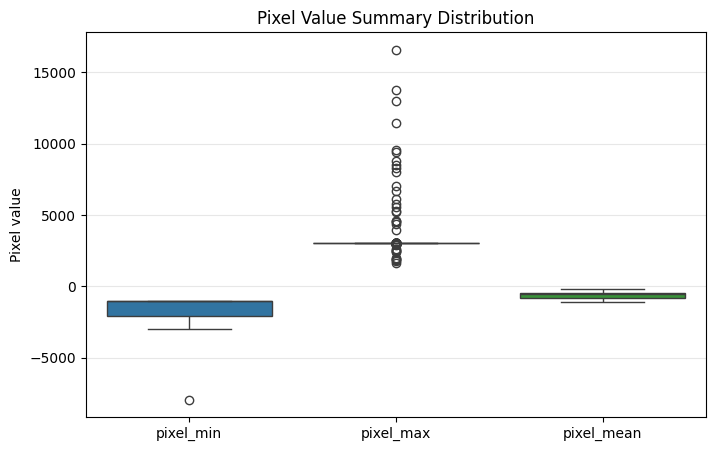

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_colonog = df_colonog[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_colonog)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

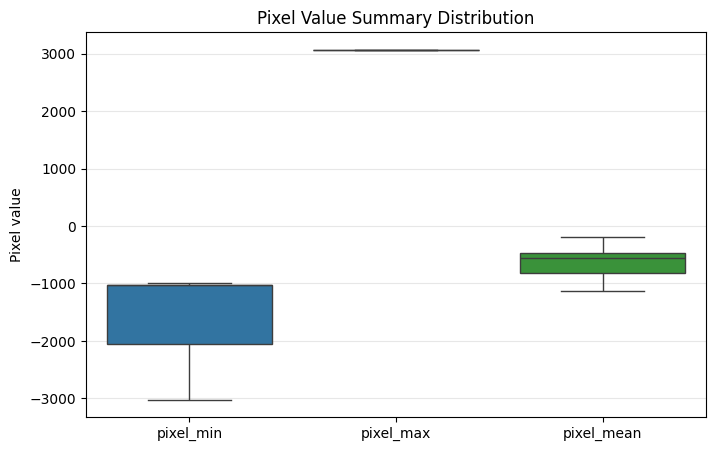

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_colonog = df_colonog[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_colonog, showfliers=False)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

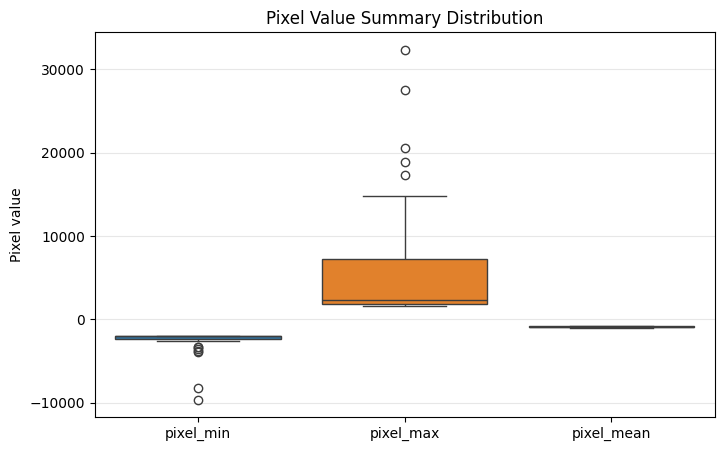

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_COVID = df_COVID[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_COVID)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

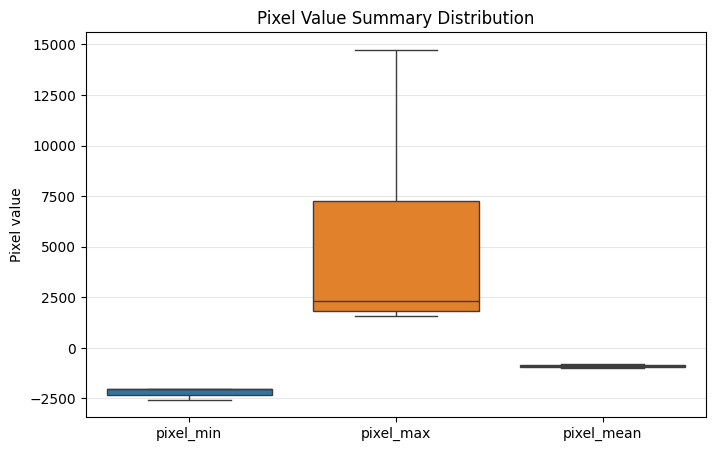

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_COVID = df_COVID[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_COVID, showfliers=False)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

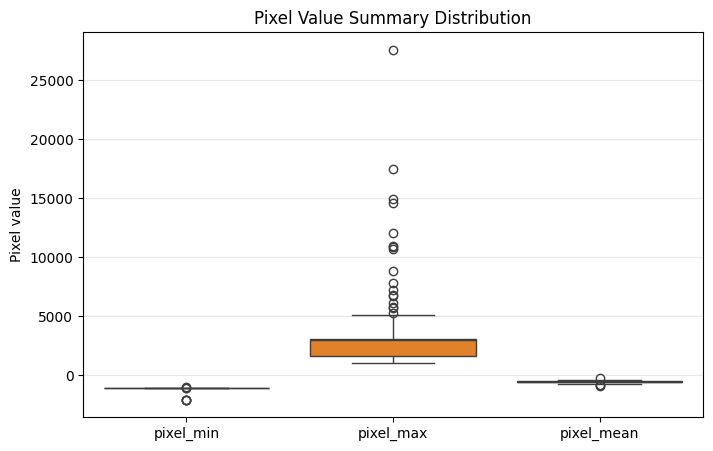

In [19]:
plot_df_MSD = df_MSD[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_MSD)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

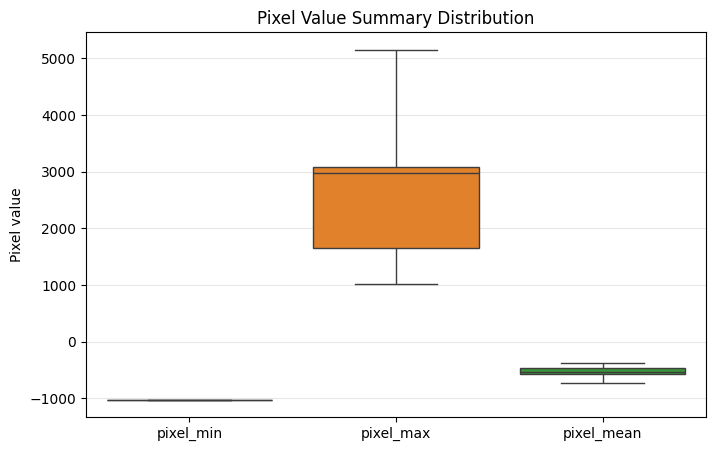

In [20]:
plot_df_MSD = df_MSD[["pixel_min", "pixel_max", "pixel_mean"]]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df_MSD, showfliers=False)
plt.title("Pixel Value Summary Distribution")
plt.ylabel("Pixel value")
plt.show()

In [21]:
outliers = df_colonog.sort_values("pixel_max", ascending=False)
outliers[["patient_id", "file_name", "pixel_max", "pixel_mean", "pixel_min"]]


,patient_id,file_name,pixel_max,pixel_mean,pixel_min
504,1.3.6.1.4.1.9328.50.4.0534,1.3.6.1.4.1.9328.50.4.0534.nii.gz,16603.0,-780.528487,-7949.0
161,1.3.6.1.4.1.9328.50.4.0172,1.3.6.1.4.1.9328.50.4.0172.nii.gz,13742.0,-715.738780,-2048.0
586,1.3.6.1.4.1.9328.50.4.0619,1.3.6.1.4.1.9328.50.4.0619.nii.gz,12977.0,-831.214891,-2655.0
250,1.3.6.1.4.1.9328.50.4.0267,1.3.6.1.4.1.9328.50.4.0267.nii.gz,11470.0,-862.228339,-2048.0
509,1.3.6.1.4.1.9328.50.4.0539,1.3.6.1.4.1.9328.50.4.0539.nii.gz,9535.0,-826.769046,-2048.0
...,...,...,...,...,...
770,CTC-2971792019,CTC-2971792019.nii.gz,1937.0,-411.494835,-1024.0
48,1.3.6.1.4.1.9328.50.4.0051,1.3.6.1.4.1.9328.50.4.0051.nii.gz,1901.0,-527.755241,-1024.0
321,1.3.6.1.4.1.9328.50.4.0344,1.3.6.1.4.1.9328.50.4.0344.nii.gz,1879.0,-457.678878,-1024.0
275,1.3.6.1.4.1.9328.50.4.0296,1.3.6.1.4.1.9328.50.4.0296.nii.gz,1795.0,-502.392240,-1024.0


## HU(pixel) 이상치 처리 방법

- 임의로 값을 정해서 clipping
- min-max normalization
- 고정 HU windowing 
- min-max는 이상치에 쉽게 흔들리기 때문에 percentile을 사용하는게 좋을 수 있음

## 제조사별 분석
- 고려해야 하는것
    - pixel수치
    - slice수
- 제조사 간의 차이를 줄이기 위해 고정 HU windowing을 적용하는게 좋을 수 있음 단 제조사별로 고정HU를 다르게 주는 건 위헙
    - 나중에 모델 성능을 비교하면서 HU값을 조정
covid-19, msd-t10의 제조사는 알려지지 않음(official)

In [22]:
metadata["Patient Id"] = metadata["Patient Id"].astype(str)
df["patient_id"] = df["patient_id"].astype(str)

merged = df.merge(
    metadata,
    left_on="patient_id",
    right_on="Patient Id",
    how="left"
)

merged[["patient_id", "Manufacturer", "Manufacturer Model", "pixel_min", "pixel_max", "pixel_mean", "slice_count"]].head()

,patient_id,Manufacturer,Manufacturer Model,pixel_min,pixel_max,pixel_mean,slice_count
0,1.3.6.1.4.1.9328.50.4.0001,SIEMENS,Sensation 64,-1024.0,3071.0,-517.375594,604
1,1.3.6.1.4.1.9328.50.4.0002,SIEMENS,Sensation 64,-1024.0,3071.0,-473.238943,637
2,1.3.6.1.4.1.9328.50.4.0003,SIEMENS,Sensation 64,-1024.0,3071.0,-509.206354,663
3,1.3.6.1.4.1.9328.50.4.0004,SIEMENS,Sensation 64,-1024.0,3071.0,-581.287551,520
4,1.3.6.1.4.1.9328.50.4.0005,SIEMENS,Sensation 16,-1024.0,3071.0,-395.712978,401


In [23]:
merged["Manufacturer"].value_counts()

Manufacturer
SIEMENS               477
GE MEDICAL SYSTEMS    222
Philips                30
TOSHIBA                21
Name: count, dtype: int64

In [24]:
merged.groupby("Manufacturer")[["pixel_mean", "slice_count"]].describe()

pixel_mean                                       \
                        count        mean         std          min   
Manufacturer                                                         
GE MEDICAL SYSTEMS      222.0 -922.010519  102.116868 -1127.786275   
Philips                  30.0 -458.638482   79.254272  -596.470372   
SIEMENS                 477.0 -505.548881   80.961424  -723.112440   
TOSHIBA                  21.0 -739.184184   74.863111  -881.756412   

                                                                    \
                           25%         50%         75%         max   
Manufacturer                                                         
GE MEDICAL SYSTEMS -997.378330 -941.298191 -876.972491 -609.342723   
Philips            -523.344255 -466.839561 -413.812524 -245.297998   
SIEMENS            -559.444779 -503.855629 -450.929782 -184.600910   
TOSHIBA            -780.528487 -734.475281 -679.661119 -625.665443   

                   slice_count                                               \
                         count        mean        std    min     25%    50%   
Manufacturer                                                                  
GE MEDICAL SYSTEMS       222.0  536.450450  53.868911  407.0  500.00  532.5   
Philips                   30.0  562.633333  61.098272  412.0  532.75  556.5   
SIEMENS                  477.0  542.580713  60.106071   85.0  504.00  546.0   
TOSHIBA                   21.0  542.238095  57.236269  444.0  501.00  538.0   

                                   
                       75%    max  
Manufacturer                       
GE MEDICAL SYSTEMS  570.00  736.0  
Philips             606.25  716.0  
SIEMENS             579.00  687.0  
TOSHIBA             576.00  644.0

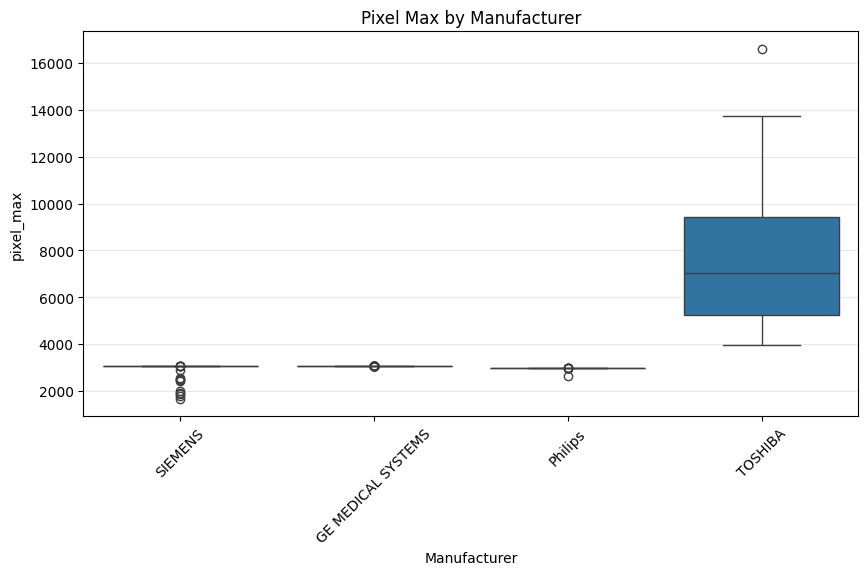

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x="Manufacturer", y="pixel_max")
plt.xticks(rotation=45)
plt.title("Pixel Max by Manufacturer")
plt.show()

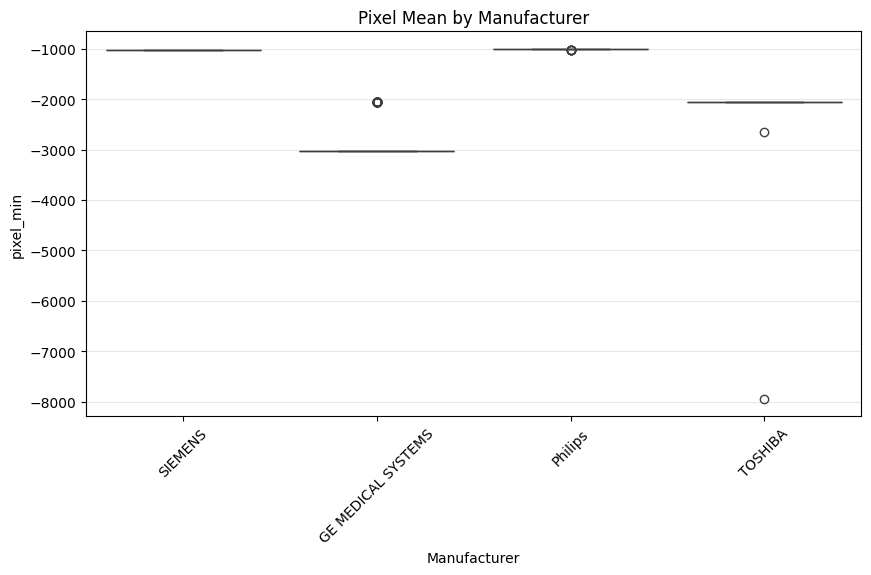

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x="Manufacturer", y="pixel_min")
plt.xticks(rotation=45)
plt.title("Pixel Mean by Manufacturer")
plt.show()

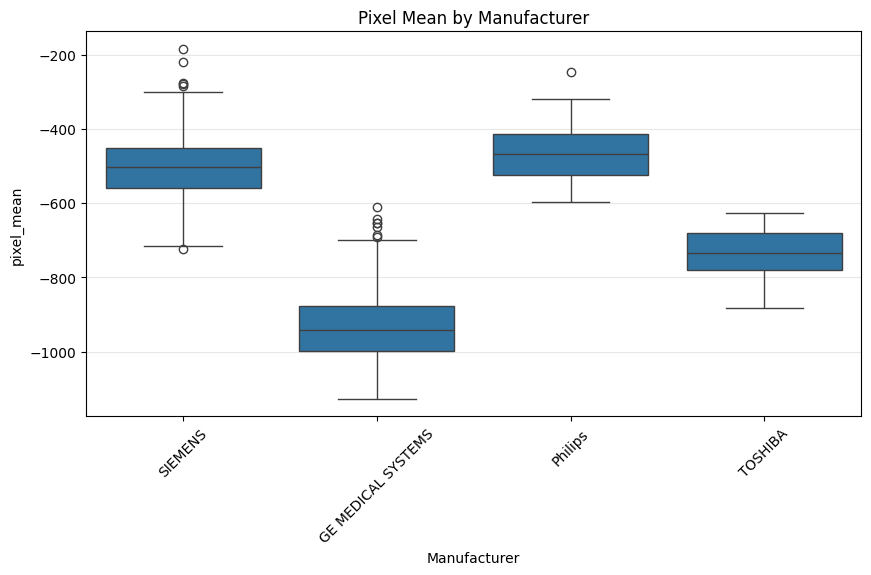

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x="Manufacturer", y="pixel_mean")
plt.xticks(rotation=45)
plt.title("Pixel Mean by Manufacturer")
plt.show()

## percentile 방법
- 이상치의 영향을 줄임
- min/max보다 이상치에 강건함
- COVID-19, MSD-T10데이터셋은 제조사 정보가 없으므로 COVID-19, MSD-T10의 percentile 분포가 COLONOG와 비슷하면, COLONOG 기준으로 정한 고정 HU window를 전체 데이터에 그대로 적용해도 타당
- 비슷하지 않다면 그많큼 상한과 하한을 맞춰주면 됨

In [32]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd

volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\COLONOG")
files = sorted(volume_dir.glob("*.nii.gz"))

rows = []

for path in files:
    arr = np.asanyarray(nib.load(path).dataobj)
    p01, p1, p50, p99, p995, p999 = np.percentile(
        arr,
        [0.1, 1, 50, 99, 99.5, 99.9]
    )

    rows.append({
        "patient_id": path.name.replace(".nii.gz", ""),
        "p01": p01,
        "p1": p1,
        "p50": p50,
        "p99": p99,
        "p995": p995,
        "p999": p999,
    })

df_pct = pd.DataFrame(rows)

In [33]:
df_pct_colonog = df_pct.copy

In [39]:
df_pct.to_pickle("df_pct_colonog.pkl")

In [36]:
volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\COVID-19")
files = sorted(volume_dir.glob("*.nii.gz"))

rows1 = []

for path in files:
    arr = np.asanyarray(nib.load(path).dataobj)
    p01, p1, p50, p99, p995, p999 = np.percentile(
        arr,
        [0.1, 1, 50, 99, 99.5, 99.9]
    )

    rows1.append({
        "patient_id": path.name.replace(".nii.gz", ""),
        "p01": p01,
        "p1": p1,
        "p50": p50,
        "p99": p99,
        "p995": p995,
        "p999": p999,
    })

df_pct_COVID = pd.DataFrame(rows1)

In [40]:
df_pct_COVID.to_pickle("df_pct_COVID.pkl")

In [41]:
volume_dir = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\MSD-T10")
files = sorted(volume_dir.glob("*.nii.gz"))

rows2 = []

for path in files:
    arr = np.asanyarray(nib.load(path).dataobj)
    p01, p1, p50, p99, p995, p999 = np.percentile(
        arr,
        [0.1, 1, 50, 99, 99.5, 99.9]
    )

    rows2.append({
        "patient_id": path.name.replace(".nii.gz", ""),
        "p01": p01,
        "p1": p1,
        "p50": p50,
        "p99": p99,
        "p995": p995,
        "p999": p999,
    })

df_pct_MSD = pd.DataFrame(rows2)

In [42]:
df_pct_MSD.to_pickle("df_pct_MSD.pkl")

In [3]:
df_pct_colonog=pd.read_pickle("df_pct_colonog.pkl")
df_pct_COVID=pd.read_pickle("df_pct_COVID.pkl")
df_pct_MSD=pd.read_pickle("df_pct_MSD.pkl")

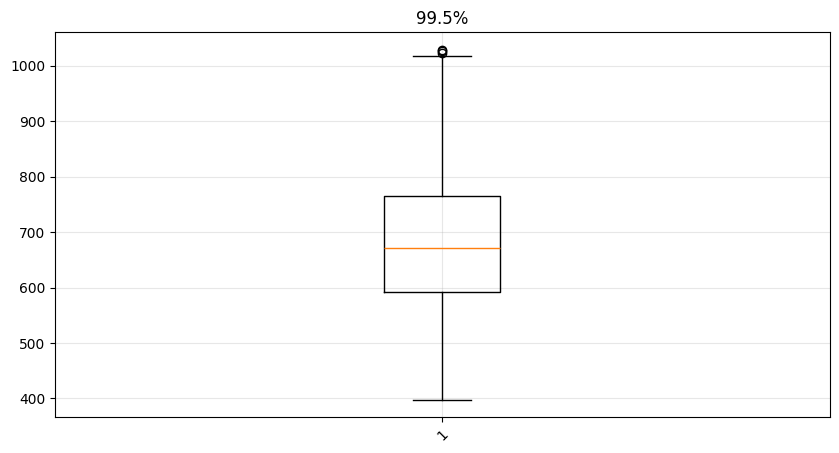

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_colonog, x="p995")
plt.xticks(rotation=45)
plt.title("99.5%")
plt.show()

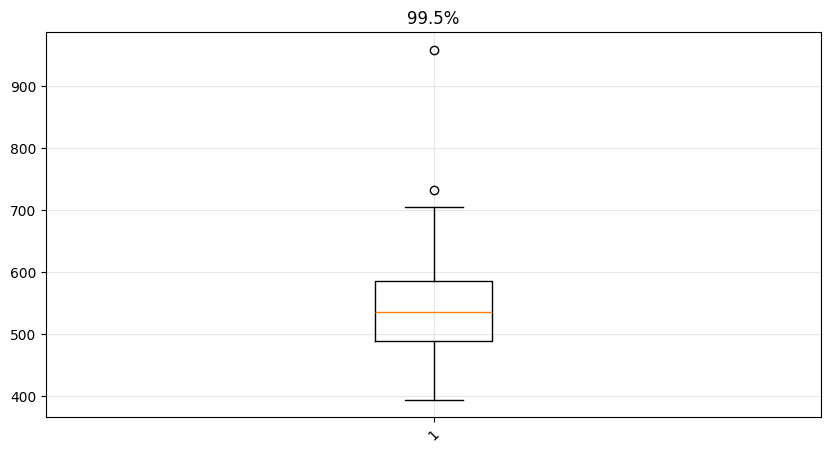

In [50]:
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_COVID, x="p995")
plt.xticks(rotation=45)
plt.title("99.5%")
plt.show()

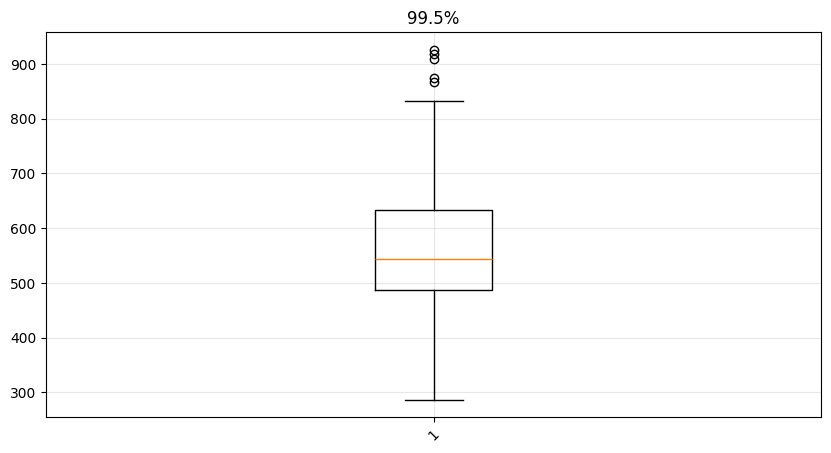

In [51]:
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_MSD, x="p995")
plt.xticks(rotation=45)
plt.title("99.5%")
plt.show()

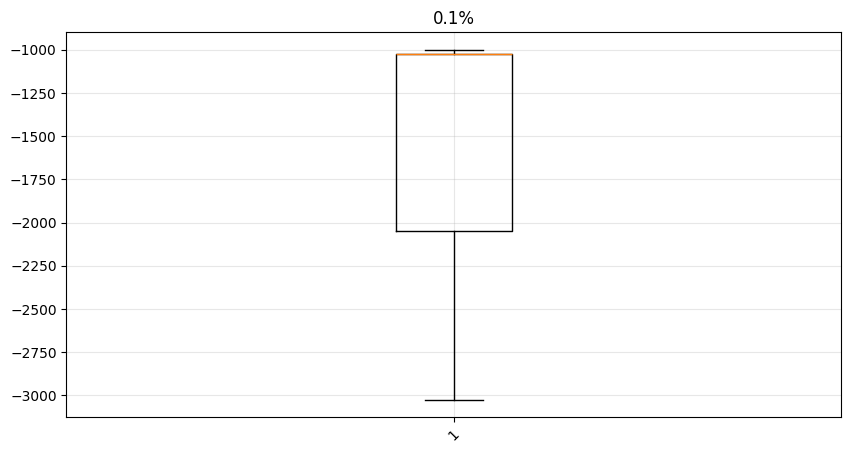

In [52]:
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_colonog, x="p01")
plt.xticks(rotation=45)
plt.title("0.1%")
plt.show()

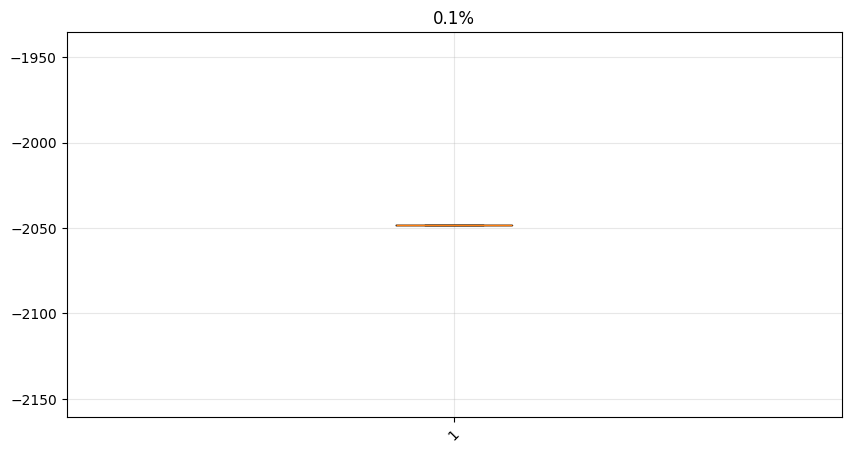

In [55]:
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_COVID, x="p01")
plt.xticks(rotation=45)
plt.title("0.1%")
plt.show()

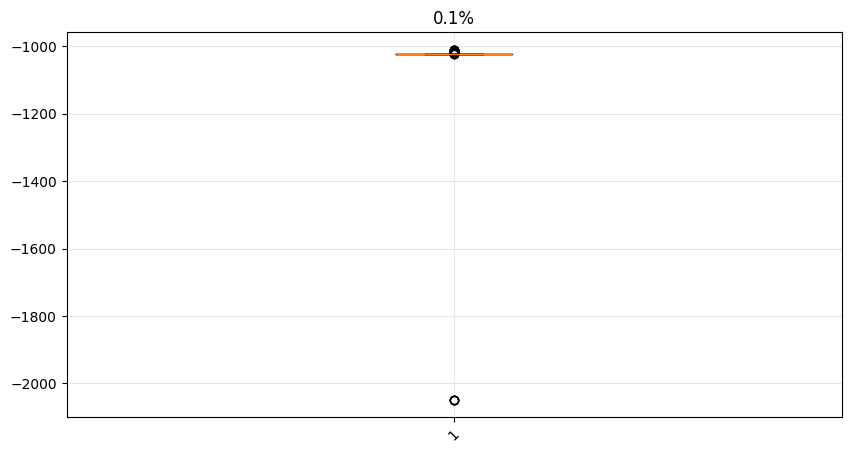

In [57]:
plt.figure(figsize=(10,5))
plt.boxplot(data=df_pct_MSD, x="p1")
plt.xticks(rotation=45)
plt.title("0.1%")
plt.show()

세 source dataset 모두 p99.5가 1000 HU 이하에 분포하여, 고강도 voxel의 대부분은 1000 HU 이내에 포함되었다. 따라서 voxel_max에서 관찰된 큰 값들은 극소수의 이상치로 판단되며, upper window를 과도하게 확장할 필요는 낮다. 반면 COVID-19 subset의 p0.1은 약 -2050 HU로 낮게 나타났으나, 이는 일반적인 CT air intensity(-1000 HU)보다 낮아 padding 또는 background 값일 가능성이 있으므로 lower bound는 -1000 HU로 고정하였다.


Source별 voxel intensity percentile을 비교한 결과, p99.5는 모든 source에서 1000 HU 이하로 나타났다. 이에 따라 high-intensity outlier의 영향을 제한하기 위해 upper bound를 2000 HU로 설정하였다. COVID-19 subset에서 p0.1이 약 -2050 HU로 낮게 관찰되었으나, 이는 일반적인 CT 공기 영역보다 낮은 값으로 padding/background의 영향으로 판단하여 lower bound는 -1000 HU로 설정하였다.


- 상한: 늘릴 필요 없음. 1500 또는 2000 추천.
- 하한: COVID 때문에 낮추지 말고 -1000 유지 추천.
- 최종 1순위: [-1000, 2000]
- 비교 실험 후보: [-1000, 1500]